# Cosine similarity of rescued compound replicates: pre-QC vs post-QC

Rescued compound/dose pairs are the 50 entries from
`../supp_figure_11_lincs_ranking_changes/map_rank_changes.ipynb`
that moved from outside the top-20 mAP rank pre-QC into the top-20 rank
post-QC (`../supp_figure_11_lincs_ranking_changes/mAP_results/improved_compounds_all_doses.csv`).

In [1]:
import pathlib

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine import (
    aes,
    element_text,
    geom_density,
    ggplot,
    labs,
    scale_fill_manual,
    theme,
    theme_bw,
)
from PyComplexHeatmap import ClusterMapPlotter, HeatmapAnnotation, anno_simple


## Helper functions

In [2]:
def compute_cosine_similarity(df: pd.DataFrame, profile_cols: list[str]) -> pd.DataFrame:
    profiles = df[profile_cols].to_numpy(dtype=float)
    profiles = np.nan_to_num(profiles, nan=0.0, posinf=0.0, neginf=0.0)
    norms = np.linalg.norm(profiles, axis=1, keepdims=True)
    normalized_profiles = np.divide(
        profiles,
        norms,
        out=np.zeros_like(profiles),
        where=norms > 0,
    )
    cosine_matrix = normalized_profiles @ normalized_profiles.T
    return pd.DataFrame(cosine_matrix, index=df["well_id"], columns=df["well_id"])


def get_profile_cols(df: pd.DataFrame) -> list[str]:
    """Numeric feature columns (excludes Metadata_* and failed_proportion)."""
    metadata_cols = df.filter(regex="^Metadata").columns.tolist()
    numeric_cols = df.select_dtypes(include="number").columns
    return [
        col
        for col in numeric_cols
        if col not in metadata_cols and col != "failed_proportion"
    ]


def get_moa_labels(moa_series: pd.Series) -> pd.Series:
    """Per-row MOA label used to group and color heatmap rows/columns.

    Missing annotations become "Unknown". Pipe-delimited multi-target
    annotations (e.g. "A|B|C") collapse to the first target plus a count, so
    each compound's own combination of targets still gets its own label. 42
    distinct labels result across the 50 rescued compound/dose rows -- every
    one gets its own color in the heatmap annotation, but since a 42-entry
    legend would be unreadable, only the dose legend is shown (see
    plot_cosine_heatmap).
    """
    display = moa_series.fillna("Unknown")
    has_multiple = display.str.contains("|", regex=False)
    return display.where(
        ~has_multiple,
        display.str.split("|").apply(lambda parts: f"{parts[0]} (+{len(parts) - 1})"),
    )


def prepare_rescued_profiles(df: pd.DataFrame, rescued_df: pd.DataFrame) -> pd.DataFrame:
    """All replicate wells for the 50 rescued (compound, dose) pairs, labeled
    by dose and MOA group.

    Rows are ordered by MOA group first (with "Unknown" pushed to the end, so
    the many compounds with no MOA annotation end up in a single contiguous
    block rather than scattered wherever their compound name happens to sort
    alphabetically), then by compound, then by dose within each compound --
    matching how the heatmap's MOA/dose row and column annotations are read.
    """
    merged = df.merge(
        rescued_df[["Metadata_broad_sample", "Metadata_dose_recode"]],
        on=["Metadata_broad_sample", "Metadata_dose_recode"],
        how="inner",
    )
    merged["well_id"] = merged["Metadata_Plate"] + ":" + merged["Metadata_Well"]
    merged["Metadata_moa_group"] = get_moa_labels(merged["Metadata_moa"])

    moa_order = [
        moa for moa in sorted(merged["Metadata_moa_group"].unique()) if moa != "Unknown"
    ] + ["Unknown"]
    moa_rank = merged["Metadata_moa_group"].map(
        {moa: rank for rank, moa in enumerate(moa_order)}
    )
    return (
        merged.assign(_moa_sort_rank=moa_rank)
        .sort_values(
            [
                "_moa_sort_rank",
                "Metadata_broad_sample",
                "Metadata_dose_recode",
                "Metadata_Plate",
                "Metadata_Well",
            ]
        )
        .drop(columns="_moa_sort_rank")
        .reset_index(drop=True)
    )


def plot_cosine_heatmap(
    cosine_df: pd.DataFrame,
    profiles: pd.DataFrame,
    moa_colors: dict[str, str],
    output_path: pathlib.Path,
) -> None:
    annotation_df = (
        profiles[["well_id", "Metadata_moa_group", "Metadata_dose_recode"]]
        .drop_duplicates()
        .set_index("well_id")
        .loc[cosine_df.index]
    )

    doses = sorted(profiles["Metadata_dose_recode"].unique())
    dose_cmap = plt.get_cmap("viridis", len(doses))
    dose_colors = {dose: mcolors.rgb2hex(dose_cmap(i)) for i, dose in enumerate(doses)}

    # PyComplexHeatmap sizes each annotation strip to a 3mm default height,
    # sized for its default (much smaller) label font -- at the bumped font
    # size below, the "MOA"/"Dose" titles are taller than that and collide
    # with each other, so each strip is given more height to match.
    anno_height = 8

    row_anno = HeatmapAnnotation(
        **{
            "": anno_simple(
                annotation_df["Metadata_moa_group"],
                colors=moa_colors,
                legend=False,
                height=anno_height,
            ),
            " ": anno_simple(
                annotation_df["Metadata_dose_recode"],
                colors=dose_colors,
                legend=False,
                height=anno_height,
            ),
        },
        axis=0,
    )

    # MOA has no legend (42 distinct colors would be unreadable as one) --
    # it's shown purely so replicate blocks are visually distinguishable by
    # color. Dose is the only annotation with a legend.
    col_anno = HeatmapAnnotation(
        **{
            "MOA": anno_simple(
                annotation_df["Metadata_moa_group"],
                colors=moa_colors,
                legend=False,
                height=anno_height,
            ),
            "Dose": anno_simple(
                annotation_df["Metadata_dose_recode"],
                colors=dose_colors,
                legend=True,
                height=anno_height,
            ),
        },
        axis=1,
    )

    # Figure is sized up alongside the font bump below so the larger
    # annotation titles, tick labels, and legend text all have room to
    # breathe -- widening the canvas rather than shrinking anything else is
    # what keeps this overlap-free.
    plt.figure(figsize=(15, 13))

    # Legend font sizes aren't exposed as direct ClusterMapPlotter kwargs, so
    # set them via rcParams for this plot. Scoped with rc_context so the bump
    # doesn't leak into later cells (e.g. the delta scatterplot below) --
    # matplotlib resolves "medium"-sized text (axes labels, tick labels,
    # legend text) relative to font.size, so this raises the "Cosine
    # similarity" colorbar label/ticks and the Dose legend together. The
    # legend_width/hpad/vgap are scaled up to match, otherwise the larger
    # legend text would clip or overlap within its own (still small) box.
    with plt.rc_context({"font.size": 22, "legend.title_fontsize": 22}):
        ClusterMapPlotter(
            data=cosine_df,
            top_annotation=col_anno,
            left_annotation=row_anno,
            cmap="magma",
            vmin=0,
            vmax=1,
            row_cluster=False,
            col_cluster=False,
            row_dendrogram=False,
            col_dendrogram=False,
            show_rownames=False,
            show_colnames=False,
            xticklabels_kws={"labelrotation": 90, "labelsize": 10},
            yticklabels_kws={"labelsize": 10},
            label="Cosine\nsimilarity",
            legend_side="right",
            legend_anchor="ax_heatmap",
            legend_width=28,
            legend_hpad=6,
            legend_vgap=7,
        )

    plt.savefig(output_path, bbox_inches="tight", dpi=600, pad_inches=0.5)
    plt.show()


def pairwise_similarities(cosine_df: pd.DataFrame) -> np.ndarray:
    """All pairwise cosine similarities between distinct wells in a cosine
    similarity matrix -- the upper triangle excluding the diagonal (which is
    each well's similarity to itself, always 1.0).
    """
    values = cosine_df.to_numpy()
    i_idx, j_idx = np.triu_indices_from(values, k=1)
    return values[i_idx, j_idx]


## Load pre-QC / post-QC single-cell profiles and the rescued compound list

In [3]:
MIN_REPLICATES = 2  # Minimum number of replicates required

# Input path for single-cell profiles
input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

# Output path for figures
output_dir = pathlib.Path("./figures")
output_dir.mkdir(parents=True, exist_ok=True)

# Load cell painting profiles (pre-QC)
pre_qc_file = pathlib.Path(input_dir, "whole_batch_pre_qc_cpd_replicates.parquet")
pre_qc_df = pd.read_parquet(pre_qc_file)
pre_qc_df = pre_qc_df.drop(columns=["broad_id", "pert_iname", "moa", "replicate_name"])

# Load cell painting profiles (post-QC)
post_qc_file = pathlib.Path(input_dir, "whole_batch_post_qc_cpd_replicates.parquet")
post_qc_df = pd.read_parquet(post_qc_file)
post_qc_df = post_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
post_qc_df["Metadata_sc_count_failed_qc"] = post_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

# Align "Metadata_sc_count_failed_qc" from post-QC df to pre-QC df using
# Metadata_Plate and Metadata_Well
pre_qc_df = pre_qc_df.merge(
    post_qc_df[["Metadata_Plate", "Metadata_Well", "Metadata_sc_count_failed_qc"]],
    on=["Metadata_Plate", "Metadata_Well"],
    how="left",
    suffixes=("", "_postqc"),
)
pre_qc_df["Metadata_sc_count_failed_qc"] = pre_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

# The 50 compound/dose pairs identified in
# ../supp_figure_11_lincs_ranking_changes/map_rank_changes.ipynb as "rescued":
# outside the top-20 mAP rank pre-QC, inside the top-20 rank post-QC.
rescued_df = pd.read_csv(
    "../supp_figure_11_lincs_ranking_changes/mAP_results/improved_compounds_all_doses.csv"
)
print(
    f"{len(rescued_df)} rescued compound/dose pairs, {rescued_df['Metadata_broad_sample'].nunique()} unique compounds"
)
rescued_df.head()


50 rescued compound/dose pairs, 46 unique compounds


,Metadata_broad_sample,Metadata_dose_recode
0,BRD-K03194791-001-04-8,1
1,BRD-A36331462-001-02-1,1
2,BRD-K06240250-001-01-6,1
3,BRD-K79095980-001-09-6,1
4,BRD-K75295174-001-05-0,1


In [4]:
pre_qc_rescued_profiles = prepare_rescued_profiles(pre_qc_df, rescued_df)
post_qc_rescued_profiles = prepare_rescued_profiles(post_qc_df, rescued_df)

pre_qc_profile_cols = get_profile_cols(pre_qc_df)
post_qc_profile_cols = get_profile_cols(post_qc_df)

# Sanity-check the scale of the cosine similarity computation before running it
for label, profiles in (
    ("Pre-QC rescued compounds", pre_qc_rescued_profiles),
    ("Post-QC rescued compounds", post_qc_rescued_profiles),
):
    print(f"{label}: {len(profiles)} wells across {profiles['Metadata_Plate'].nunique()} plates")

# The same wells should be present pre- and post-QC (QC removes cells within
# a well, not whole wells) -- verify that here since every downstream pairing
# (heatmap ordering, pairwise cosine similarity comparison) assumes it.
assert set(pre_qc_rescued_profiles["well_id"]) == set(post_qc_rescued_profiles["well_id"]), (
    "Pre-QC and post-QC well sets differ for the rescued compound/dose pairs."
)


Pre-QC rescued compounds: 243 wells across 106 plates
Post-QC rescued compounds: 243 wells across 106 plates


In [5]:
pre_qc_cosine_df = compute_cosine_similarity(pre_qc_rescued_profiles, pre_qc_profile_cols)
post_qc_cosine_df = compute_cosine_similarity(post_qc_rescued_profiles, post_qc_profile_cols)

# With clustering disabled, the heatmaps are drawn in this row/column order
# as-is -- confirm pre-QC and post-QC land in the exact same well order
# (guaranteed by prepare_rescued_profiles sorting on QC-invariant metadata)
# so the two heatmaps are directly comparable panel-to-panel.
assert list(pre_qc_cosine_df.index) == list(post_qc_cosine_df.index), (
    "Pre-QC and post-QC cosine matrices are not in the same well order."
)

print(f"Pre-QC cosine similarity matrix shape: {pre_qc_cosine_df.shape}")
print(f"Post-QC cosine similarity matrix shape: {post_qc_cosine_df.shape}")


Pre-QC cosine similarity matrix shape: (243, 243)
Post-QC cosine similarity matrix shape: (243, 243)


## Heatmaps: pairwise cosine similarity across rescued-compound wells, labeled by dose and MoA

In [6]:
# One distinct color per MoA group (42 across the 50 rescued rows). This is
# not a categorical legend palette -- with 42 entries a legend would be
# unreadable, so plot_cosine_heatmap only shows the dose legend -- it's a
# dense qualitative sweep used purely so each MoA block reads as visually
# distinct from its neighbors in the heatmap annotation strip.
moa_labels = sorted(post_qc_rescued_profiles["Metadata_moa_group"].unique())
moa_cmap = plt.get_cmap("gist_ncar", len(moa_labels))
moa_colors = {moa: mcolors.rgb2hex(moa_cmap(i)) for i, moa in enumerate(moa_labels)}
moa_colors


{'5 alpha reductase inhibitor': '#000080',
 'AKT inhibitor': '#002d45',
 'Abl kinase inhibitor (+2)': '#005b0b',
 'Aurora kinase inhibitor': '#003964',
 'CDK inhibitor': '#000ecb',
 'CDK inhibitor (+1)': '#003aff',
 'DNA alkylating agent': '#0092ff',
 'DNA inhibitor': '#00ccff',
 'EGFR inhibitor (+1)': '#00e8ff',
 'EGFR inhibitor (+2)': '#00ffe5',
 'HCV inhibitor': '#00fcbc',
 'HIV integrase inhibitor': '#00fa8e',
 'HSP inhibitor': '#00fc4d',
 'JNK inhibitor': '#0cff0c',
 'MEK inhibitor': '#33e800',
 'NADPH oxidase inhibitor': '#5bd100',
 'PLK inhibitor': '#6fe000',
 'PPAR receptor agonist': '#7bf400',
 'RNA polymerase inhibitor': '#92ff18',
 'Unknown': '#aeff30',
 'XIAP inhibitor': '#caff2e',
 'adenylyl cyclase activator': '#e7ff15',
 'antibacterial agent': '#fff600',
 'antimetabolite': '#ffe600',
 'apoptosis stimulant': '#ffd701',
 'aromatase inhibitor': '#ffc808',
 'bacterial 30S ribosomal subunit inhibitor (+1)': '#ffb40d',
 'bacterial 50S ribosomal subunit inhibitor': '#ff8108',
 

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting HeatmapAnnotations
Plotting legends..


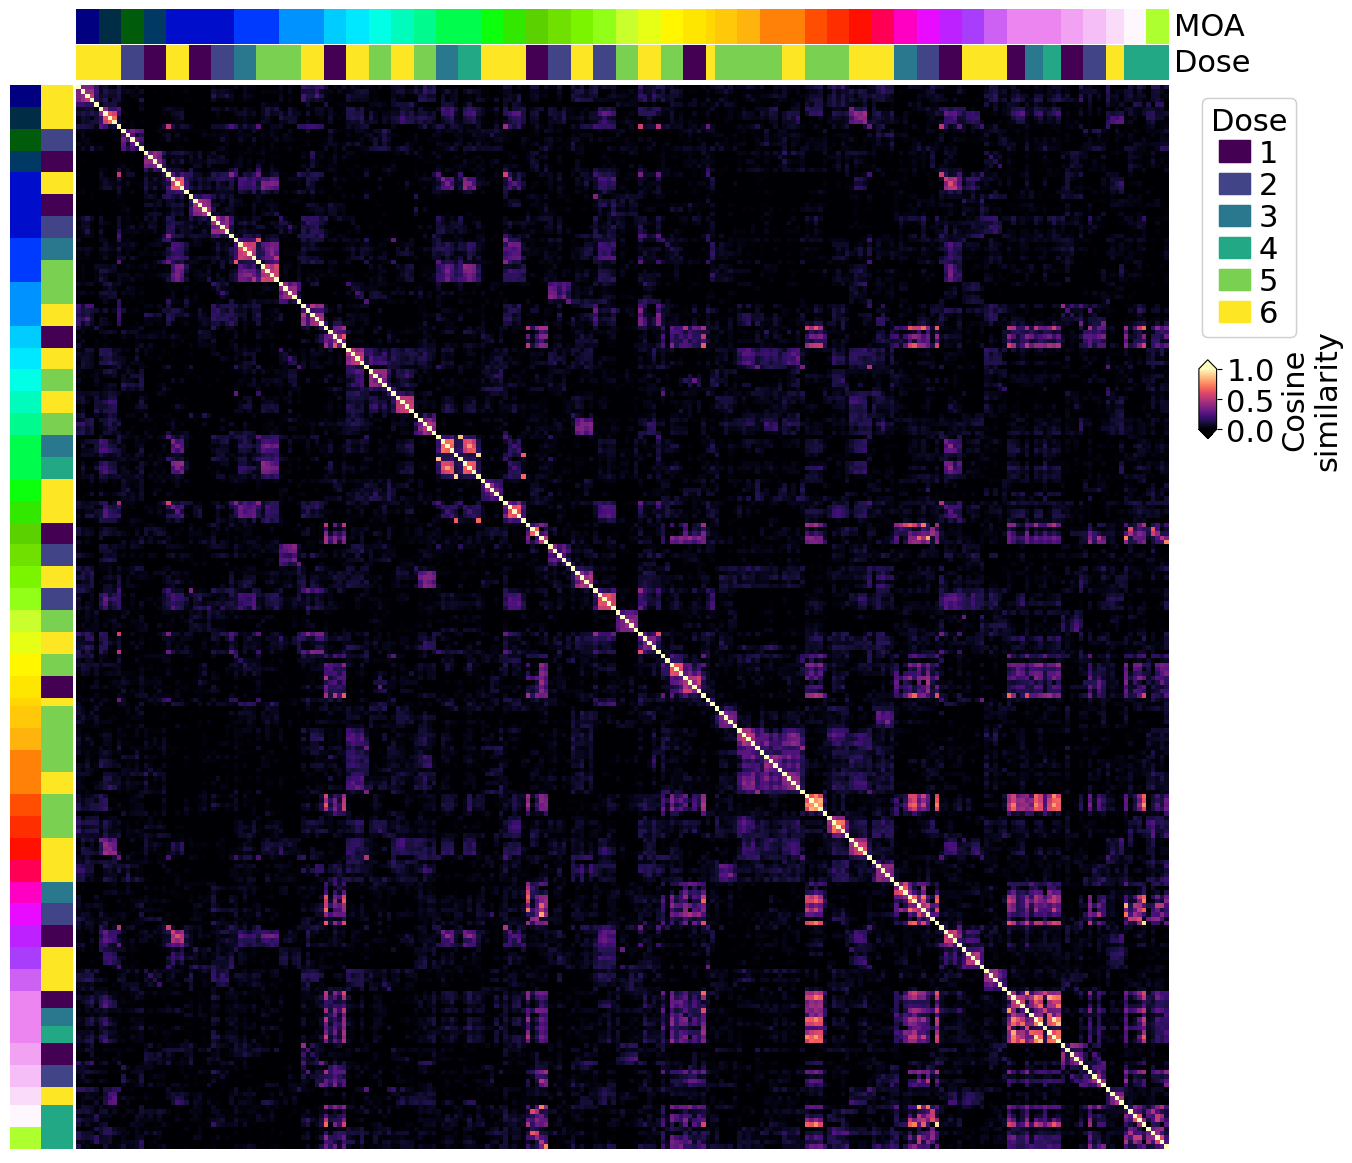

In [7]:
plot_cosine_heatmap(
    pre_qc_cosine_df,
    pre_qc_rescued_profiles,
    moa_colors,
    output_dir / "rescued_compounds_heatmap_cosine_similarity_pre_qc.png",
)


Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting HeatmapAnnotations
Plotting legends..


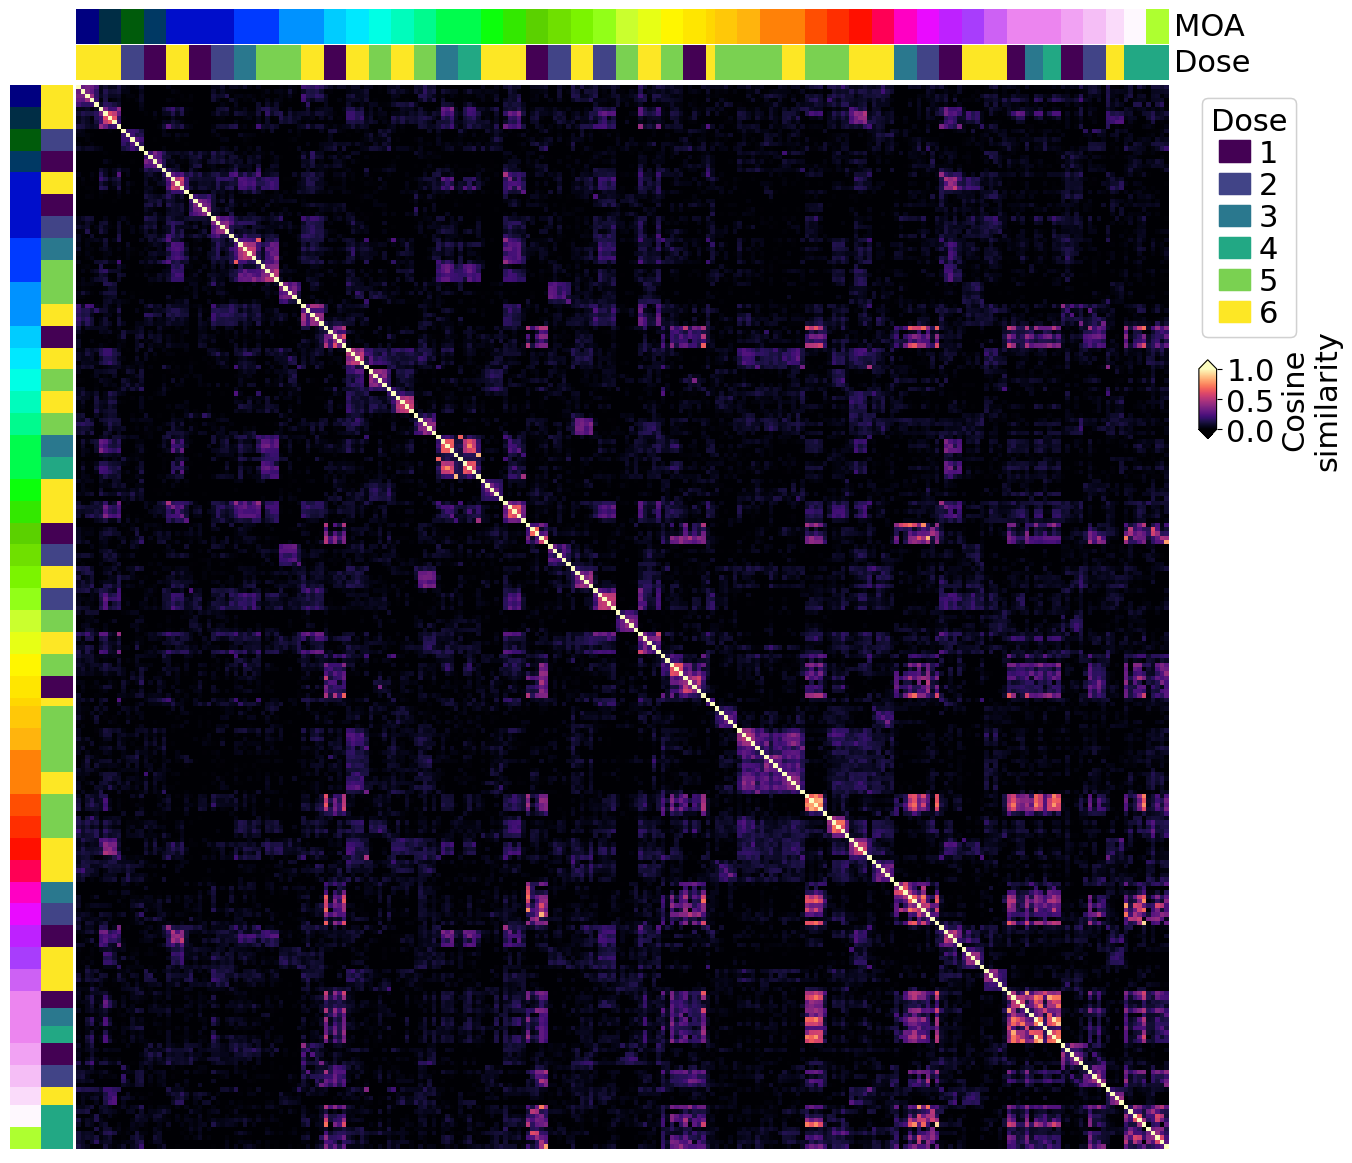

In [8]:
plot_cosine_heatmap(
    post_qc_cosine_df,
    post_qc_rescued_profiles,
    moa_colors,
    output_dir / "rescued_compounds_heatmap_cosine_similarity_post_qc.png",
)


## Pairwise cosine similarity distribution: pre-QC vs post-QC

All pairwise cosine similarities between the rescued compound/dose wells
(every well against every other well, not restricted to true replicates of
the same compound/dose), comparing the full pre-QC and post-QC distributions.

In [9]:
pairwise_df = pd.concat(
    [
        pd.DataFrame(
            {
                "cosine_similarity": pairwise_similarities(pre_qc_cosine_df),
                "QC_status": "Pre-QC",
            }
        ),
        pd.DataFrame(
            {
                "cosine_similarity": pairwise_similarities(post_qc_cosine_df),
                "QC_status": "Post-QC",
            }
        ),
    ],
    ignore_index=True,
)

print(f"{len(pairwise_df) // 2} pairwise cosine similarity values per QC status")
pairwise_df.groupby("QC_status")["cosine_similarity"].describe()


29403 pairwise cosine similarity values per QC status


,count,mean,std,min,25%,50%,75%,max
QC_status,,,,,,,,
Post-QC,29403.0,0.041573,0.096269,-0.420585,-0.013547,0.022793,0.068210,0.954055
Pre-QC,29403.0,0.041320,0.098051,-0.462400,-0.013156,0.022973,0.066983,0.941671


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 7 x 5.5 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rescued_compounds_pairwise_cosine_similarity_density.png


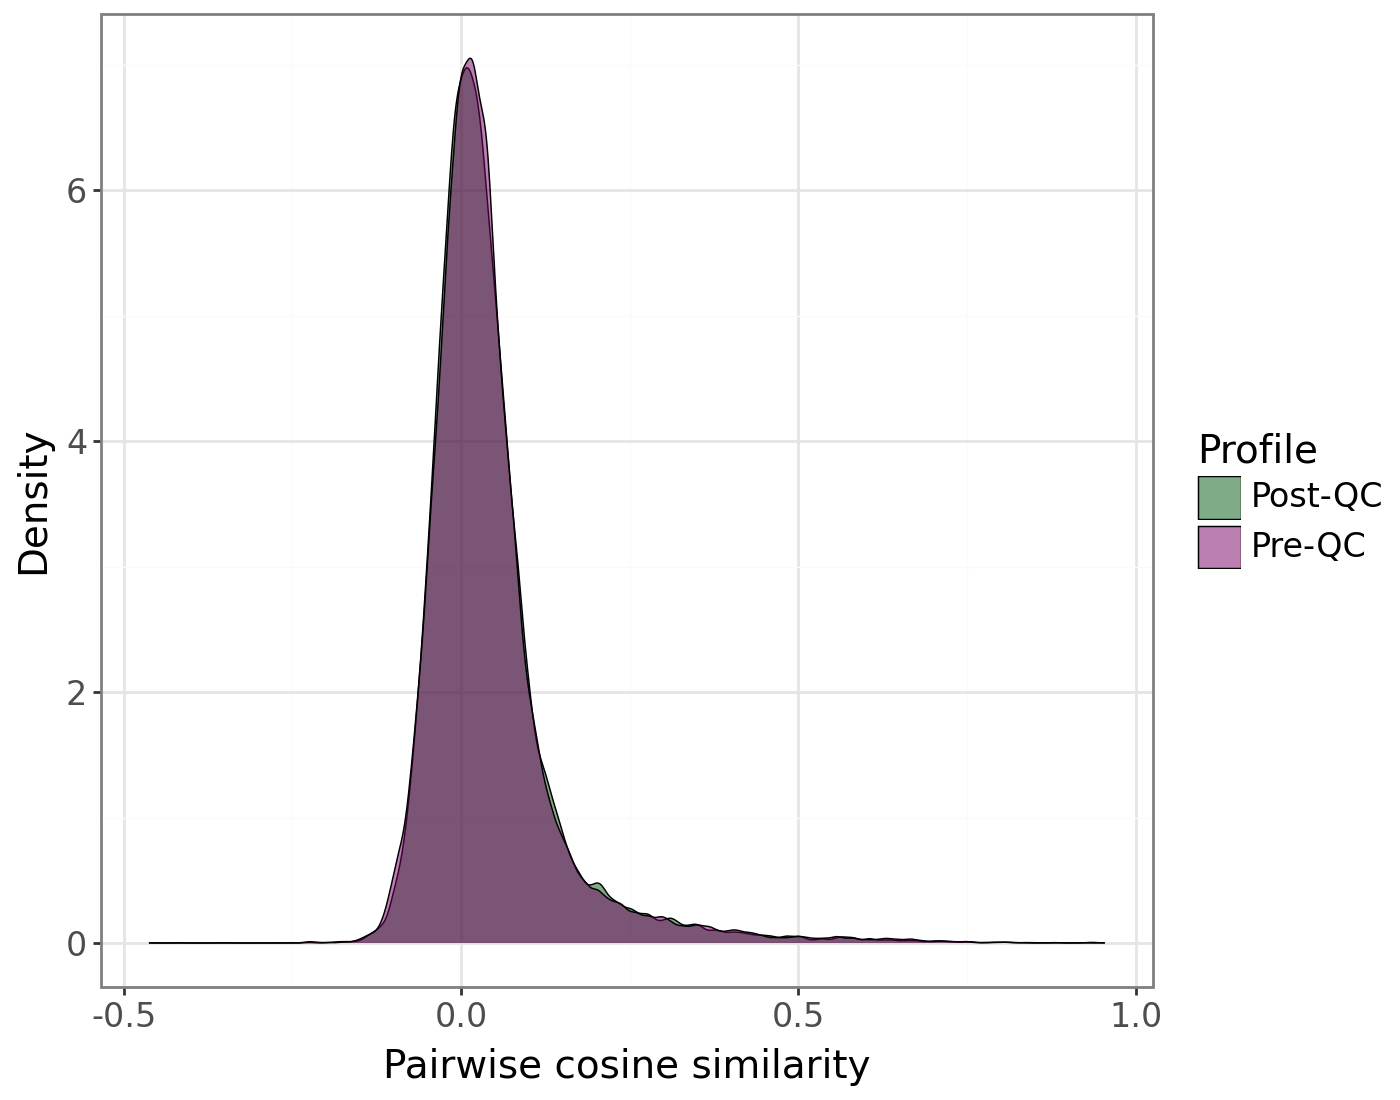

In [10]:
p = (
    ggplot(pairwise_df, aes(x="cosine_similarity", fill="QC_status"))
    + geom_density(alpha=0.5, color="black", size=0.3)
    + scale_fill_manual(values={"Pre-QC": "#790065", "Post-QC": "#00580f"})
    + labs(x="Pairwise cosine similarity", y="Density", fill="Profile")
    + theme_bw()
    + theme(
        figure_size=(7, 5.5),
        axis_title=element_text(size=14),
        axis_text=element_text(size=12),
        legend_title=element_text(size=14),
        legend_text=element_text(size=12),
        legend_position="right",
    )
)

p.save(
    output_dir / "rescued_compounds_pairwise_cosine_similarity_density.png",
    dpi=600,
)
p.show()
